# Benchmark institutionnel des formulations de Markowitz

**Objectif.** Isoler l'impact des **contraintes**, **régularisations** et **paramètres de
calibration** sur la robustesse et la **faisabilité opérationnelle** des portefeuilles, de la
formulation mathématique (QP/SOCP) au comportement **hors échantillon** par régime.

**5 formulations comparées (Phase 2).**
1. **Standard** : $\max_w\ \mu^\top w-\tfrac{\gamma}{2}w^\top\Sigma w$ s.c. $1^\top w=1$.
2. **Contraintes linéaires** : + bornes $l\le w\le u$ et levier $\sum|w_i|\le L$.
3. **Opérationnel** : + turnover $\|w-w_0\|_1\le T$ et coûts $\kappa^\top|w-w_0|$ dans l'objectif.
4. **Robust** : + pénalité d'incertitude sur $\mu$ : $-\kappa_\mu\|\Omega^{1/2}w\|_2$ (SOCP).
5. **Markowitz++** : tout simultanément, **calibré** 

## 1. Données et configuration

In [1]:
import sys, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".."); sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import portfolio_lab as pl
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

USE_SYNTHETIC = False
START, END = "2007-01-01", "2025-12-31"

In [2]:
constituents = pl.get_sp500_constituents()
SELECTOR = pl.StratifiedBySector(n_total=80, seed=42)
#SELECTOR = pl.AllUniverse()
# SELECTOR = pl.TopN(50)             # N premiers (ALPHABÉTIQUE)
# SELECTOR = pl.RandomN(50, seed=42) # aléatoire reproductible
universe = SELECTOR.select(constituents)
if USE_SYNTHETIC:
    prices = pl.make_synthetic_prices(constituents.loc[universe], START, END)
else:
    prices = pl.clean_prices(pl.download_prices(universe, START, END))
print(f"Univers : {prices.shape[1]} actifs | {prices.shape[0]} obs "
      f"({prices.index[0].date()} -> {prices.index[-1].date()})")

# Estimateurs FIGÉS (on isole l'effet de la FORMULATION, pas de μ/Σ).
MEAN_EST = pl.SampleMean()
COV_EST  = pl.EmpiricalCovariance()
WINDOW, STEP, TC_BPS, RF = 252, 21, 10.0, 0.04

[OK] 503 composants récupérés depuis Wikipédia.


Univers : 65 actifs | 4695 obs (2007-05-04 -> 2025-12-30)


## 2. Benchmark des 5 formulations (hors échantillon)


In [3]:
variants = {
    "1. Standard":     pl.make_variant("standard"),
    "2. Linéaire":     pl.make_variant("linear", w_max=0.10),
    "3. Opérationnel": pl.make_variant("operational", w_max=0.10, tc_bps=TC_BPS),
    "4. Robust":       pl.make_variant("robust", w_max=0.10),
    "5. Markowitz++":  pl.make_variant("pp", w_max=0.10, tc_bps=TC_BPS),
}
t0 = time.time()
res = pl.run_markowitz_benchmark(prices, variants, mean_estimator=MEAN_EST, cov_estimator=COV_EST,
                                 window=WINDOW, step=STEP, tc_bps=TC_BPS, rf_annual=RF)
print(f"5 backtests en {time.time()-t0:.1f}s")
tbl = pl.markowitz_metrics_table(res)
display(tbl.round(3))

5 backtests en 12.4s


,CAGR (%),Vol annualized (%),Sharpe,Sortino,Calmar,Max drawdown (%),Average turnover,Cumulative cost (%),Max leverage,Weight stability (Δw),Rebalances
1. Standard,7.877,29.577,0.131,0.125,0.136,-57.782,0.799,16.938,1.000,0.799,212.000
2. Linéaire,12.564,21.259,0.403,0.378,0.224,-56.088,0.496,10.526,1.000,0.496,212.000
3. Opérationnel,13.664,21.616,0.447,0.419,0.248,-55.127,0.295,6.252,1.000,0.295,212.000
4. Robust,11.747,19.621,0.395,0.370,0.228,-51.579,0.479,10.146,1.000,0.479,212.000
5. Markowitz++,12.410,20.626,0.408,0.382,0.228,-54.351,0.376,7.979,1.000,0.376,212.000


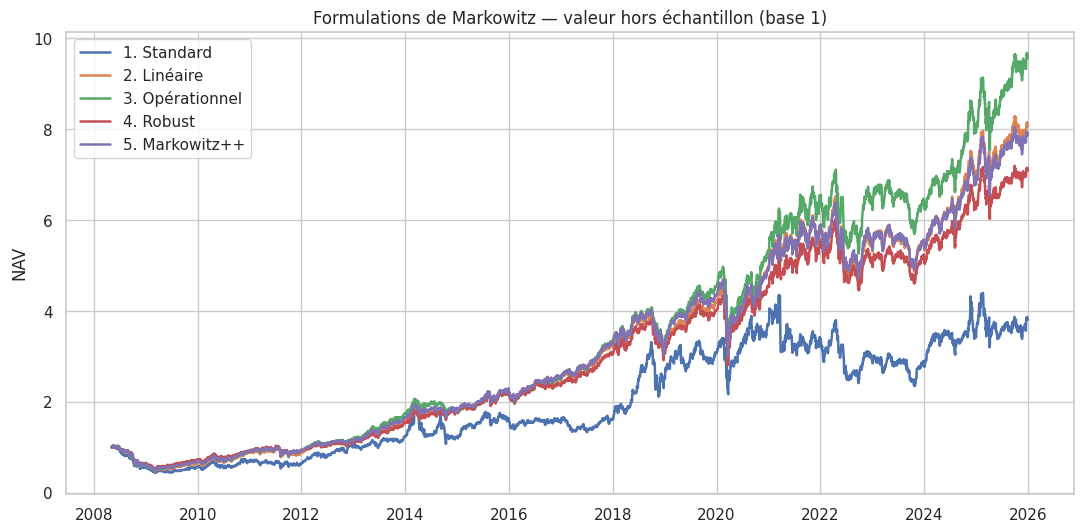

In [4]:
# Courbes de valeur hors échantillon (base 1).
fig, ax = plt.subplots(figsize=(13, 6))
for name, r in res.items():
    ax.plot(r.history.index, r.history["nav"], lw=1.8, label=name)
ax.set_title("Formulations de Markowitz — valeur hors échantillon (base 1)")
ax.set_ylabel("NAV"); ax.legend(); plt.show()

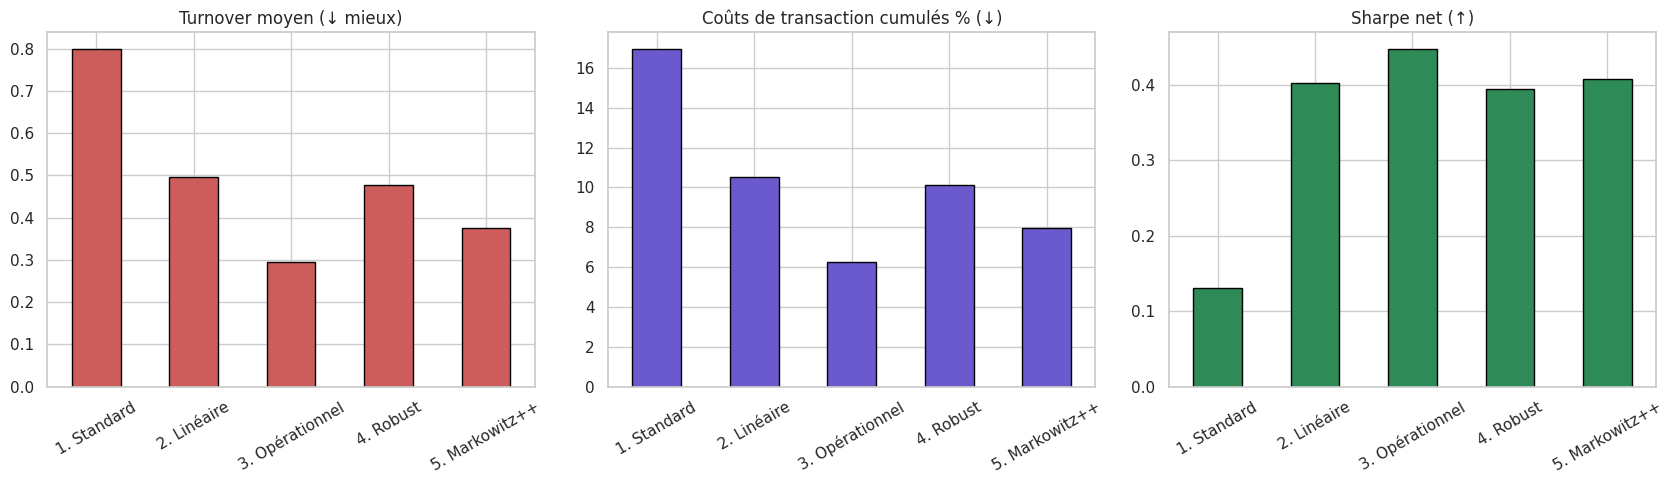

In [5]:
# Réalisme opérationnel : turnover moyen vs coûts cumulés vs stabilité.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
tbl["Average turnover"].plot(kind="bar", ax=axes[0], color="indianred", edgecolor="black")
axes[0].set_title("Turnover moyen (↓ mieux)")
tbl["Cumulative cost (%)"].plot(kind="bar", ax=axes[1], color="slateblue", edgecolor="black")
axes[1].set_title("Coûts de transaction cumulés % (↓)")
tbl["Sharpe"].plot(kind="bar", ax=axes[2], color="seagreen", edgecolor="black")
axes[2].set_title("Sharpe net (↑)")
for a in axes: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 3. Analyse par **régime de marché**
On découpe la performance OOS par fenêtres datées : **krach COVID** (fév–avr 2020),
**resserrement 2022**, **marché calme 2023-2024**. Un bon Markowitz institutionnel résiste en
crise (drawdown contenu).

In [6]:
REGIMES = {
    "COVID (fév-avr 2020)": ("2020-02-15", "2020-04-30"),
    "Resserrement 2022":    ("2022-01-01", "2022-12-31"),
    "Calme 2023-2024":      ("2023-01-01", "2024-12-31"),
}
def regime_metrics(ret, lo, hi):
    r = ret.loc[lo:hi].dropna()
    if len(r) < 5: return {"Sharpe": np.nan, "Vol %": np.nan, "MaxDD %": np.nan}
    nav = (1+r).cumprod()
    vol = r.std(ddof=1)*np.sqrt(252)
    cagr = nav.iloc[-1]**(252/len(r)) - 1
    mdd = (nav/nav.cummax()-1).min()
    return {"Sharpe": (cagr-RF)/vol if vol>0 else np.nan, "Vol %": vol*100, "MaxDD %": mdd*100}

for reg,(lo,hi) in REGIMES.items():
    print(f"\n=== {reg} ===")
    rows = {n: regime_metrics(r.history["strategy_return"], lo, hi) for n,r in res.items()}
    display(pd.DataFrame(rows).T.round(3))


=== COVID (fév-avr 2020) ===


,Sharpe,Vol %,MaxDD %
1. Standard,-0.812,80.568,-36.202
2. Linéaire,-0.955,69.110,-35.247
3. Opérationnel,-0.982,72.197,-36.446
4. Robust,-0.921,69.184,-35.086
5. Markowitz++,-0.972,70.751,-35.811



=== Resserrement 2022 ===


,Sharpe,Vol %,MaxDD %
1. Standard,-0.644,27.617,-36.505
2. Linéaire,-0.486,23.205,-31.089
3. Opérationnel,-0.286,23.170,-25.968
4. Robust,-0.621,20.548,-26.172
5. Markowitz++,-0.512,21.601,-25.957



=== Calme 2023-2024 ===


,Sharpe,Vol %,MaxDD %
1. Standard,0.175,22.874,-23.262
2. Linéaire,0.585,14.995,-17.380
3. Opérationnel,0.509,14.853,-17.242
4. Robust,0.512,13.960,-15.089
5. Markowitz++,0.507,14.491,-16.791


## 4. Tuned Markowitz++

Calibration par **montée de coordonnées** (+25 % / −20 %) des hyperparamètres
$(\gamma_{\text{risk}},\gamma_{\text{trade}})$ sur la période **In-Sample** (≤ 2022), puis
application **Out-of-Sample** (2023-2025). On compare le ++ **calibré** au ++ par défaut.

In [7]:
IS_END = "2022-12-31"
prices_is = prices.loc[:IS_END]
prices_oos = prices.loc["2022-01-01":]      # 1 an de recouvrement pour amorcer la fenêtre

t0 = time.time()
pen_star, score_star, hist = pl.calibrate_markowitzpp(
    prices_is, pl.make_variant("pp", w_max=0.10, tc_bps=TC_BPS),
    mean_estimator=MEAN_EST, cov_estimator=COV_EST,
    params=("gamma_risk", "gamma_trade"), window=WINDOW, step=STEP,
    tc_bps=TC_BPS, rf_annual=RF, max_passes=3)
print(f"Calibration IS en {time.time()-t0:.1f}s | score={score_star:.3f} | évaluations={len(hist)}")
print(f"γ* : gamma_risk={pen_star.gamma_risk:.3f}, gamma_trade={pen_star.gamma_trade:.3f}")

Calibration IS en 19.4s | score=0.109 | évaluations=7
γ* : gamma_risk=9.766, gamma_trade=1.953


In [8]:
# OOS : ++ calibré vs ++ défaut vs Opérationnel
tuned = pl.MarkowitzPlusPlus(pl.make_variant("pp", w_max=0.10).constraints, pen_star, TC_BPS)
oos = pl.run_markowitz_benchmark(prices_oos, {
    "Markowitz++ (tuned)":   tuned,
    "Markowitz++ (défaut)":  pl.make_variant("pp", w_max=0.10, tc_bps=TC_BPS),
    "Opérationnel":          pl.make_variant("operational", w_max=0.10, tc_bps=TC_BPS),
}, mean_estimator=MEAN_EST, cov_estimator=COV_EST, window=WINDOW, step=STEP, tc_bps=TC_BPS, rf_annual=RF)
display(pl.markowitz_metrics_table(oos).round(3))
print("Si le ++ calibré bat le ++ défaut en Sharpe NET OOS, la calibration a apporté de la valeur (H3).")

,CAGR (%),Vol annualized (%),Sharpe,Sortino,Calmar,Max drawdown (%),Average turnover,Cumulative cost (%),Max leverage,Weight stability (Δw),Rebalances
Markowitz++ (tuned),12.269,15.265,0.542,0.518,0.775,-15.834,0.402,1.446,1.000,0.402,36.000
Markowitz++ (défaut),12.356,16.008,0.522,0.495,0.729,-16.957,0.406,1.461,1.000,0.406,36.000
Opérationnel,13.139,16.566,0.552,0.524,0.769,-17.091,0.315,1.133,1.000,0.315,36.000


Si le ++ calibré bat le ++ défaut en Sharpe NET OOS, la calibration a apporté de la valeur (H3).


## 5. Analyse de **sensibilité** (±20 % sur μ et Σ)
Variation L1 des poids optimaux sous perturbation ±20 % des inputs. Un portefeuille robuste est
**peu sensible** (mean_l1 faible) → moins d'overfitting aux erreurs d'estimation.

,mean_l1,max_l1
1. Standard,0.418,0.886
2. Linéaire,0.292,0.611
3. Opérationnel,0.292,0.611
4. Robust,0.277,0.358
5. Markowitz++,0.262,0.412


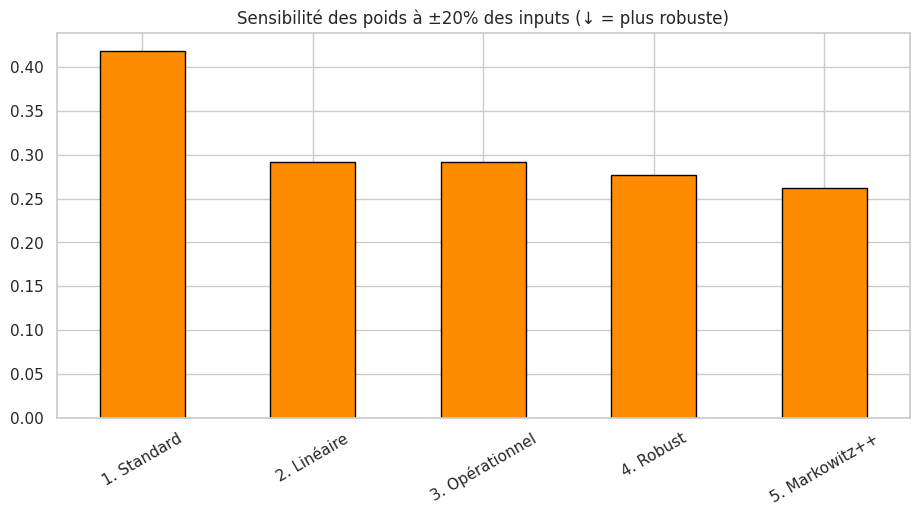

In [9]:
win = pl.compute_returns(prices.iloc[-WINDOW:], "simple")
mu = MEAN_EST.estimate(win)*252
Sig = COV_EST.estimate(win).values*252
sens = {}
for name, opt in variants.items():
    s = pl.weight_sensitivity(mu, Sig, opt, pct=0.20, n_dirs=20)
    sens[name] = {"mean_l1": s["mean_l1"], "max_l1": s["max_l1"]}
sens = pd.DataFrame(sens).T
display(sens.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
sens["mean_l1"].plot(kind="bar", ax=ax, color="darkorange", edgecolor="black")
ax.set_title("Sensibilité des poids à ±20% des inputs (↓ = plus robuste)")
ax.tick_params(axis="x", rotation=30); plt.show()

## Matrice de décision & recommandations

In [10]:
# Coût computationnel : temps d'UNE résolution par variante.
solve_time = {}
for name, opt in variants.items():
    t0 = time.time()
    for _ in range(5): opt.solve(mu, Sig, w_prev=np.ones(len(mu))/len(mu), mu_uncertainty=np.diag(Sig))
    solve_time[name] = (time.time()-t0)/5*1000   # ms

# Scores qualitatifs (simplicité, intérêt institutionnel) — propres à la formulation.
qual = {
    "1. Standard":     {"Simplicité": 5, "Intérêt instit.": 2},
    "2. Linéaire":     {"Simplicité": 4, "Intérêt instit.": 3},
    "3. Opérationnel": {"Simplicité": 3, "Intérêt instit.": 5},
    "4. Robust":       {"Simplicité": 3, "Intérêt instit.": 4},
    "5. Markowitz++":  {"Simplicité": 1, "Intérêt instit.": 5},
}
decision = pd.DataFrame({
    "Perf nette OOS (Sharpe ↑)":  tbl["Sharpe"].rank(ascending=False),
    "Robustesse (sensib. ↓)":     sens["mean_l1"].rank(ascending=True),
    "Faisabilité (turnover ↓)":   tbl["Average turnover"].rank(ascending=True),
    "Coût calcul (ms ↓)":         pd.Series(solve_time).rank(ascending=True),
    "Simplicité":                 pd.Series({k:v["Simplicité"] for k,v in qual.items()}).rank(ascending=False),
    "Intérêt institutionnel":     pd.Series({k:v["Intérêt instit."] for k,v in qual.items()}).rank(ascending=False),
})
decision["RANG MOYEN"] = decision.mean(axis=1)
display(decision.sort_values("RANG MOYEN").round(2))
print("\nTemps de résolution (ms):", {k: round(v,1) for k,v in solve_time.items()})
print("Meilleur compromis (rang moyen) :", decision["RANG MOYEN"].idxmin())

,Perf nette OOS (Sharpe ↑),Robustesse (sensib. ↓),Faisabilité (turnover ↓),Coût calcul (ms ↓),Simplicité,Intérêt institutionnel,RANG MOYEN
3. Opérationnel,1.000,4.000,1.000,4.000,3.500,1.500,2.500
5. Markowitz++,2.000,1.000,2.000,5.000,5.000,1.500,2.750
2. Linéaire,3.000,3.000,4.000,2.000,2.000,4.000,3.000
4. Robust,4.000,2.000,3.000,3.000,3.500,3.000,3.080
1. Standard,5.000,5.000,5.000,1.000,1.000,5.000,3.670



Temps de résolution (ms): {'1. Standard': 5.7, '2. Linéaire': 6.9, '3. Opérationnel': 7.8, '4. Robust': 7.3, '5. Markowitz++': 12.4}
Meilleur compromis (rang moyen) : 3. Opérationnel


## 6. Compléments — risque de queue et concentration des poids

### a. VaR et Expected Shortfall sur la distribution des rendements
`portfolio_lab.metrics` calcule VaR et CVaR/Expected Shortfall de façon **historique** (quantile empirique de la distribution réalisée, pas une hypothèse gaussienne) : la VaRα est la perte au quantile α, l'ES est la perte moyenne **au-delà** de ce quantile. Hypothèse implicite : la distribution future ressemble à la distribution historique observée (pas de changement de régime) — c'est une mesure descriptive du passé, pas une garantie pour l'avenir.

**Portefeuille représentatif** : formulation **Markowitz++** (5ᵉ des 5 formulations comparées en section 2) — contraintes long-only, poids max 10 %, turnover max 40 %, levier = 1 ; pénalités γ_risk=5, γ_trade=1, κ_μ=1 ; μ = SampleMean (fixé), Σ = Empirique (fixée), coûts de transaction 10 bps inclus dans l'objectif, walk-forward fenêtre/pas = `WINDOW`/`STEP` jours (historique complet du backtest, pas un simple split passé/futur). **Cette définition est propre à `markowitz.ipynb`** : `return.ipynb` (max_utility / μ=meilleur IC / Σ=Ledoit-Wolf) et `covariance.ipynb` (min_variance / Σ=best_stat) utilisent chacun un portefeuille représentatif différent — ne pas comparer directement une valeur numérique de cette section à celle d'un autre notebook sans remettre ces définitions en regard.

Portefeuille représentatif : Markowitz++ / μ=SampleMean / Σ=Empirique / w_max=10% / turnover_max=40% / coûts=10bps / fenêtre=252j / pas=21j.
VaR 95% = 1.97% | VaR 99% = 3.63% | ES (95%) = 3.14%


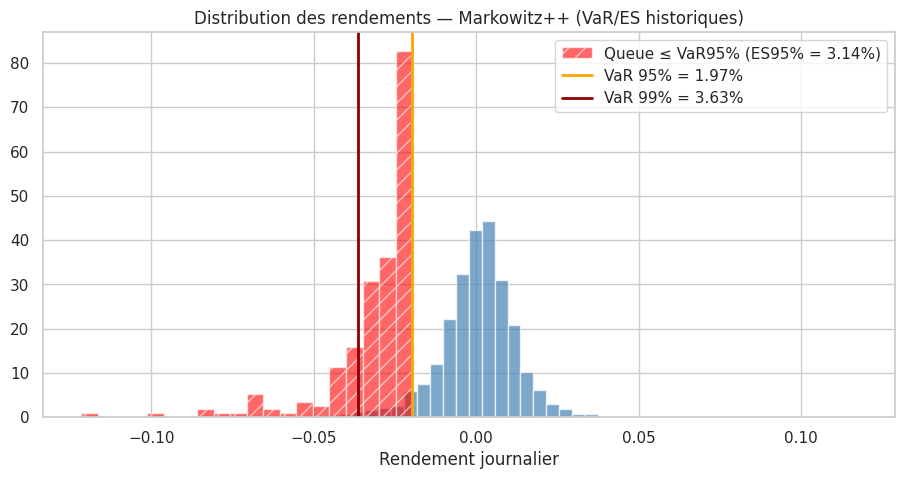

In [11]:
port_ret_mkw = res["5. Markowitz++"].history["strategy_return"].dropna()
print(f"Portefeuille représentatif : Markowitz++ / μ=SampleMean / Σ=Empirique / w_max=10% / "
      f"turnover_max=40% / coûts=10bps / fenêtre={WINDOW}j / pas={STEP}j.")

var95 = pl.value_at_risk(port_ret_mkw, 0.05)
var99 = pl.value_at_risk(port_ret_mkw, 0.01)
es95  = pl.conditional_var(port_ret_mkw, 0.05)
print(f"VaR 95% = {var95*100:.2f}% | VaR 99% = {var99*100:.2f}% | ES (95%) = {es95*100:.2f}%")

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(port_ret_mkw, bins=60, density=True, alpha=0.7, color="steelblue")
tail = port_ret_mkw[port_ret_mkw <= -var95]
ax.hist(tail, bins=20, density=True, alpha=0.6, color="red", hatch="//",
        label=f"Queue ≤ VaR95% (ES95% = {es95*100:.2f}%)")
ax.axvline(-var95, color="orange", lw=2, label=f"VaR 95% = {var95*100:.2f}%")
ax.axvline(-var99, color="darkred", lw=2, label=f"VaR 99% = {var99*100:.2f}%")
ax.set_title("Distribution des rendements — Markowitz++ (VaR/ES historiques)")
ax.set_xlabel("Rendement journalier"); ax.legend(); plt.show()

### b. Coefficient de Gini sur les poids du portefeuille optimal
Le Gini mesure la **concentration** d'une distribution de poids (0 = parfaitement égalitaire, 1 = concentration totale sur un seul actif). Hypothèse : poids non négatifs sommant à 1 (portefeuille long-only), ce qui est le cas des 3 constructions comparées ici. Cette section calcule 3 portefeuilles **ad hoc** (1/N, Min-Variance, Max Sharpe) — les 5 formulations de ce notebook (Standard/Linéaire/Opérationnel/Robust/Markowitz++) sont toutes des variantes moyenne-variance et ne couvrent pas ces 3 méthodes d'allocation. μ et Σ sont estimés sur les `WINDOW` derniers jours disponibles (même fenêtre que l'analyse de sensibilité, section 5).

Équipondéré 1/N   0.000
Min-Variance      0.805
Max Sharpe        0.833
dtype: float64

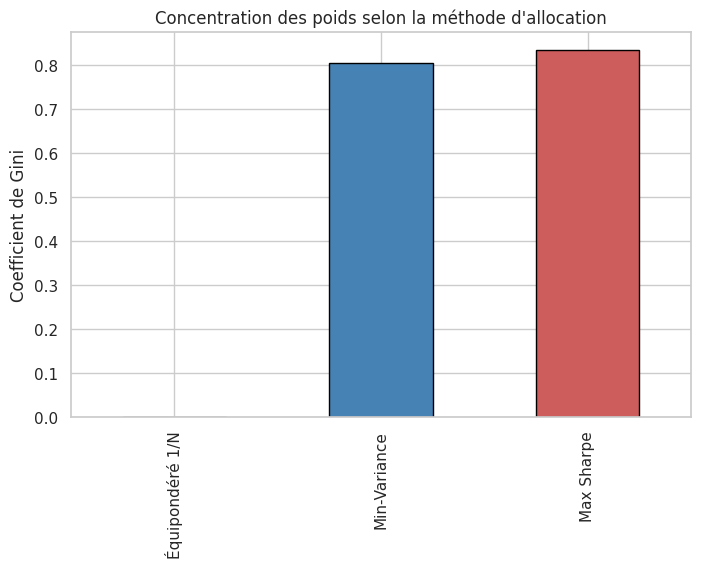

In [12]:
def gini(w):
    """Gini standard sur poids non négatifs sommant à 1 : G = 2*Σ(i·w_i)/(n·Σw) - (n+1)/n,
    w trié par ordre croissant, i = 1..n (formule de Lorenz discrète)."""
    w = np.clip(np.sort(np.asarray(w, dtype=float)), 0, None)
    n = len(w)
    if w.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return float(2 * np.sum(idx * w) / (n * w.sum()) - (n + 1) / n)

w_eq        = pl.EqualWeightOptimizer().solve(mu, Sig, w_max=1.0)
w_minvar    = pl.CVXPYOptimizer().solve(mu, Sig, objective="min_variance", w_max=0.10)
w_maxsharpe = pl.CVXPYOptimizer().solve(mu, Sig, objective="max_sharpe", rf=RF, w_max=0.10)

gini_table = pd.Series({
    "Équipondéré 1/N": gini(w_eq),
    "Min-Variance":    gini(w_minvar),
    "Max Sharpe":      gini(w_maxsharpe),
})
display(gini_table.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
gini_table.plot(kind="bar", ax=ax, color=["seagreen", "steelblue", "indianred"], edgecolor="black")
ax.set_ylabel("Coefficient de Gini"); ax.set_title("Concentration des poids selon la méthode d'allocation")
plt.show()

# Journalisation du run (`results/`)



In [13]:
from portfolio_lab.reporting import RunReport

rep = RunReport("markowitz", results_dir="results")
rep.capture(
    prices=prices, selector=SELECTOR,
    requested_n=getattr(SELECTOR, "n_total", getattr(SELECTOR, "n", None)),
    period=(START, END), use_synthetic=USE_SYNTHETIC, w_max=0.10,
    mean_estimators={"μ": MEAN_EST}, cov_estimators={"Σ": COV_EST},
    extra={
        "Fenêtre d'estimation": f"{WINDOW} périodes",
        "Pas / détention": f"{STEP} périodes",
        "Coûts de transaction": f"{TC_BPS} bps",
        "Taux sans risque (annuel)": f"{RF:.2%}",
        "Formulations comparées": "; ".join(variants),
    },
)
ns = globals()
rep.add_if(ns, "res",  "Backtest des formulations (OOS)")
rep.add_if(ns, "oos",  "Calibration IS → OOS (++ tuned vs défaut)")
rep.add_if(ns, "sens", "Sensibilité des poids (±20 % sur μ et Σ)")
rep.add_if(ns, "qual", "Scores qualitatifs (simplicité / intérêt instit.)")
print("Rapport écrit :", rep.save())   # rep.save(fmt="both") pour tenter un PDF (pandoc)


Rapport écrit : results/markowitz__2026-06-21_152036.md
